# Utils

In [2]:
import numpy as np
import pandas as pd
from typing import List, Dict


#from Evaluation.OntoMapping_benchmark.compute_scores import open_res_table


In [3]:
def clean_ai_code(x):
    # Case 1: NaN → keep as is (or return None)
    if pd.isna(x):
        return None

    # Case 2: float like 12345.0 → convert to int → string
    if isinstance(x, float):
        if x.is_integer():
            return str(int(x))
        else:
            return str(x)  # keep decimal if meaningful

    # Case 3: already string → return as is
    return str(x)

def safe_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return [x]

# metrics functions

def precision_at_k(preds: List[str], gt: List[str], k: int) -> float:
    preds_k = preds[:k]
    if k == 0:
        return 0.0
    return len(set(preds_k) & set(gt)) / k


def recall_at_k(preds: List[str], gt: List[str], k: int) -> float:
    if len(gt) == 0:
        return 0.0
    preds_k = preds[:k]
    return len(set(preds_k) & set(gt)) / len(gt)

def hits_at_k(preds: List[str], gt: List[str], k: int) -> int:
    preds_k = preds[:k]
    return int(len(set(preds_k) & set(gt)) > 0)

def mrr(preds: List[str], gt: List[str], k: int = None) -> float:
    if k is not None:
        preds = preds[:k]

    for rank, p in enumerate(preds, start=1):
        if p in gt:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(preds: List[str], gt: List[str], k: int) -> float:
    preds_k = preds[:k]

    dcg = 0.0
    for i, p in enumerate(preds_k):
        if p in gt:
            dcg += 1.0 / np.log2(i + 2)

    # Ideal DCG
    ideal_hits = min(len(gt), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0.0

def oracle_recall_at_k(preds: List[str], gt: List[str], k: int) -> int:
    preds_k = preds[:k]
    return int(len(set(preds_k) & set(gt)) > 0)

def recall_at_k_capped(preds, gt, k):
    if len(gt) == 0:
        return 0.0
    preds_k = preds[:k]
    denom = min(len(gt), k)
    return len(set(preds_k) & set(gt)) / denom

def ai_metrics(ai_code: str, gt: List[str]) -> Dict:
    if pd.isna(ai_code):
        return {"hit@1": 0}

    return {"hit@1": int(ai_code in gt)}

def conditional_ai_accuracy(row, k=5):
    gt = set(row['gt'])
    preds = row['preds'][:k]
    ai = row['AI_code']

    if len(set(preds) & gt) == 0:
        return None  # retrieval failed

    return int(ai in gt)


def evaluate_mapper(df: pd.DataFrame, target_onto: str, k_values=[1, 2, 3, 4, 5]) -> Dict:
    results = {}

    # Ensure lists
    df = df.copy()
    df['gt'] = df[f'{target_onto}_ids'].apply(safe_list)
    df['preds'] = df['se_codes'].apply(safe_list)

    for k in k_values:
        precs, recs, hits, mrrs, ndcgs, oracle, capped = [], [], [], [], [], [], []

        for _, row in df.iterrows():
            gt = row['gt']
            preds = row['preds']

            precs.append(precision_at_k(preds, gt, k))
            recs.append(recall_at_k(preds, gt, k))
            hits.append(hits_at_k(preds, gt, k))
            mrrs.append(mrr(preds, gt, k))
            ndcgs.append(ndcg_at_k(preds, gt, k))
            oracle.append(oracle_recall_at_k(preds, gt, k))
            capped.append(recall_at_k_capped(preds, gt, k))

        results[f'precision@{k}'] = np.mean(precs)
        results[f'recall@{k}'] = np.mean(recs)
        results[f'hits@{k}'] = np.mean(hits)
        results[f'mrr@{k}'] = np.mean(mrrs)
        results[f'ndcg@{k}'] = np.mean(ndcgs)
        results[f'oracle_recall@{k}'] = np.mean(oracle)
        results[f'capped_recall@{k}'] = np.mean(capped)

    # AI metrics
    ai_scores = df.apply(lambda row: ai_metrics(row['AI_code'], row['gt']), axis=1)

    results['ai_hit@1'] = np.mean([x["hit@1"] for x in ai_scores])
    return results


def results_to_dataframe(results: Dict) -> pd.DataFrame:
    return pd.DataFrame([results]).T.rename(columns={0: "score"})

def plot_metrics_vs_k(results: dict, vocabularies: str):
    ks = sorted(set(int(k.split('@')[1]) for k in results if '@' in k and 'ai' not in k))
    metrics = ['hits', 'mrr']
    color_map = {
    'hits': 'green',
    'mrr': 'purple'
}
    fig, ax = plt.subplots()
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.set_xticks(ks)

    for metric in metrics:
        values = [results.get(f"{metric}@{k}", 0) for k in ks]
        ax.plot(ks, values, marker='o', label=metric, color=color_map[metric])
        ax.set_ylim(0.85, 1)
    ax.set_xlabel("k")
    ax.set_ylabel("Score")
    ax.set_title(vocabularies)
    ax.legend()
    ax.grid(color='lightgray')
    plt.savefig(f"results/OntoMapping_benchmark/baseline_plot/{vocabularies}.png", facecolor="white", bbox_inches="tight")

    plt.show()

In [3]:
def plot_recall_vs_oracle(results):
    ks = sorted(set(int(k.split('@')[1]) for k in results if 'recall@' in k))

    recall = [results[f"recall@{k}"] for k in ks]
    oracle = [results[f"oracle_recall@{k}"] for k in ks]
    capped_recall = [results[f"capped_recall@{k}"] for k in ks]


    plt.figure()
    plt.plot(ks, recall, marker='o', label='capped_recall')
    plt.plot(ks, oracle, marker='o',     label='oracle_recall')
    plt.plot(ks, oracle, marker='o', linestyle='--', label='capped_recall')

    plt.xlabel("k")
    plt.ylabel("Score")
    plt.title("Recall vs. Oracle")
    plt.legend()
    plt.grid(True)
    plt.show()

# Baseline results

In [24]:
from Evaluation.OntoMapping_benchmark.src.OM_pipeline import setup_logging
import logging
logger = setup_logging()

def open_res_table(vocabularies: str):
    vocabularies_list = vocabularies.split()
    source_onto = vocabularies_list[0]
    target_onto = vocabularies_list[1]
    logging.info("Opening mapping table")
    try:
        res_df = pd.read_csv(f'results/OntoMapping_benchmark/rag_output_25_{source_onto}_{target_onto}.csv')
        res_df[f'{target_onto}_ids'] = res_df[f'{target_onto}_ids'].apply(lambda x: parse_to_list_of_strings(x))
        res_df['se_codes'] = res_df['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
        res_df['AI_code'] =  res_df['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)
        logging.info(f"Mapping table: {res_df.shape} with columns: {res_df.columns}")
        return res_df
    except FileNotFoundError as e:
        logger.error(f"Error loading results: {e}", exc_info=True)
        return None

## SNOMEDCT vs ICD10

In [7]:
sno_icd = open_res_table('SNOMEDCT_US ICD10')
icd_sno = open_res_table('ICD10 SNOMEDCT_US')

In [8]:
print(f'num of mappings: {len(sno_icd)}')
print(f'num of mappings: {len(icd_sno)}')


num of mappings: 974
num of mappings: 974


In [9]:
sno_icd_res = evaluate_mapper(sno_icd, 'ICD10')
icd_sno_res = evaluate_mapper(icd_sno, 'SNOMEDCT_US')

In [ ]:
sno_icd_res

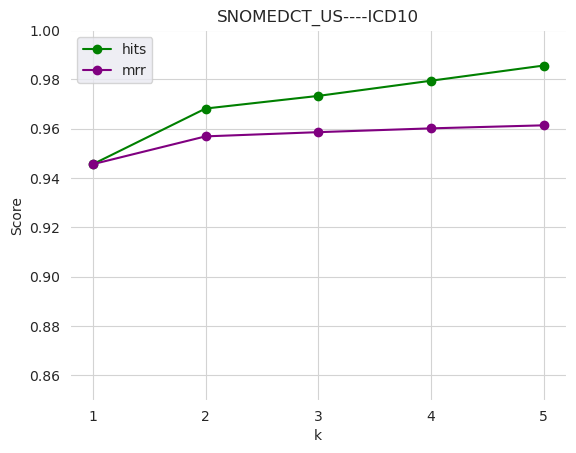

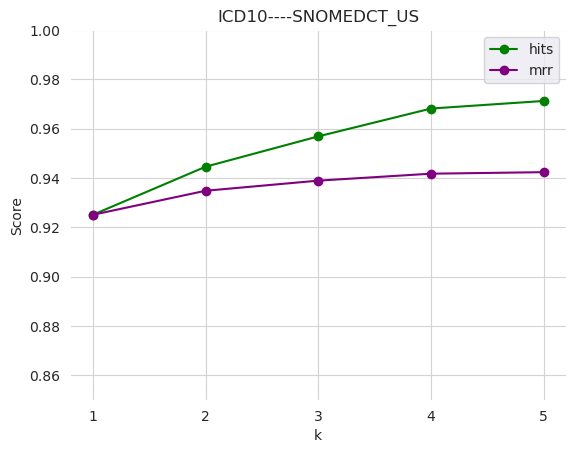

In [19]:
plot_metrics_vs_k(sno_icd_res, 'SNOMEDCT_US----ICD10')
plot_metrics_vs_k(icd_sno_res, 'ICD10----SNOMEDCT_US')

In [11]:
sno_icd_res['ai_hit@1']


0.9537987679671458

In [12]:
icd_sno_res['ai_hit@1']

0.9312114989733059

In [20]:
sno_icd_res['hits@1'] - sno_icd_res['ai_hit@1']

-0.008213552361396315

In [21]:
icd_sno_res['hits@1'] - icd_sno_res['ai_hit@1']

-0.006160164271047153

## SNOMEDCT vs LOINC


/home/bbf1146/miniconda3/envs/lu_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
sno_lnc = open_res_table('SNOMEDCT_US LNC')
lnc_sno = open_res_table('LNC SNOMEDCT_US')
sno_lnc_res = evaluate_mapper(sno_lnc, 'LNC')
lnc_sno_res = evaluate_mapper(lnc_sno, 'SNOMEDCT_US')

In [ ]:
print(f'num of mappings: {len(sno_lnc)}')
print(f'num of mappings: {len(lnc_sno)}')

In [ ]:
plot_metrics_vs_k(sno_lnc_res, 'SNOMEDCT_US----LOINC')
plot_metrics_vs_k(lnc_sno_res, 'LOINC----SNOMEDCT_US')

In [ ]:
sno_lnc_res['ai_hit@1']


In [ ]:
sno_lnc_res['hits@1'] - sno_lnc_res['ai_hit@1']

In [ ]:
lnc_sno_res['ai_hit@1']


In [ ]:
lnc_sno_res['hits@1'] - lnc_sno_res['ai_hit@1']


## ICD10 vs LOINC

In [ ]:
icd_lnc = open_res_table('ICD10 LNC')
lnc_icd = open_res_table('LNC ICD10')
icd_lnc_res = evaluate_mapper(icd_lnc, 'LNC')
lnc_icd_res = evaluate_mapper(lnc_icd, 'ICD10')

In [ ]:
print(f'num of mappings: {len(icd_lnc)}')
print(f'num of mappings: {len(lnc_icd)}')

In [ ]:
plot_metrics_vs_k(icd_lnc_res, 'ICD10----LOINC')
plot_metrics_vs_k(lnc_icd_res, 'LOINC----ICD10')

In [ ]:
icd_lnc_res['ai_hit@1']


In [ ]:
icd_lnc_res['hits@1'] - icd_lnc_res['ai_hit@1']

In [ ]:
lnc_icd_res['ai_hit@1']

In [ ]:
lnc_icd_res['hits@1'] - lnc_icd_res['ai_hit@1']

## NCBI vs SNOMEDCT

In [ ]:
ncbi_sno = open_res_table('NCBI SNOMEDCT_US')
sno_ncbi = open_res_table('SNOMEDCT_US NCBI')
print(f'num of mappings: {len(ncbi_sno)}')
print(f'num of mappings: {len(sno_ncbi)}')

In [ ]:
ncbi_sno.tail()

In [ ]:
sno_ncbi.tail()

In [ ]:
ncbi_sno_res = evaluate_mapper(ncbi_sno, 'SNOMEDCT_US')
sno_ncbi_res = evaluate_mapper(sno_ncbi, 'NCBI')

In [ ]:
plot_metrics_vs_k(ncbi_sno_res, 'NCBI----SNOMEDCT_US')
plot_metrics_vs_k(sno_ncbi_res, 'SNOMEDCT_US----NCBI')

In [ ]:
ncbi_sno_res['ai_hit@1']

In [ ]:
ncbi_sno_res['hits@1'] - ncbi_sno_res['ai_hit@1']

In [ ]:
sno_ncbi_res['ai_hit@1']

In [ ]:
sno_icd_res['hits@1'] - sno_icd_res['ai_hit@1']

## SNOMED vs RXNORM

In [25]:
rxnorm_sno = open_res_table('RXNORM SNOMEDCT_US')
sno_rxnorm = open_res_table('SNOMEDCT_US RXNORM')


In [26]:
print(f'num of mappings: {len(rxnorm_sno)}')
print(f'num of mappings: {len(sno_rxnorm)}')

num of mappings: 1851
num of mappings: 1851


In [27]:
rxnorm_sno_res = evaluate_mapper(rxnorm_sno, 'SNOMEDCT_US')
sno_rxnorm_res = evaluate_mapper(sno_rxnorm, 'RXNORM')

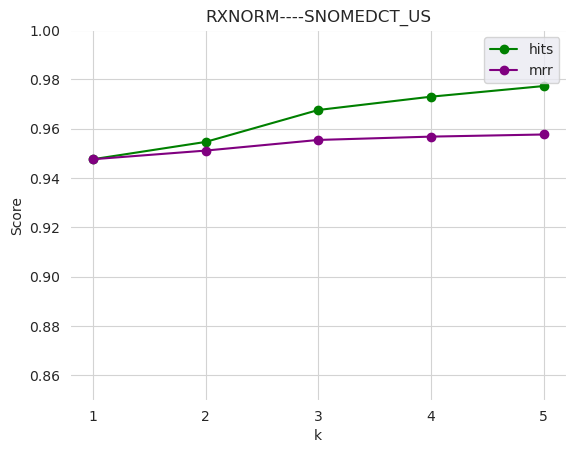

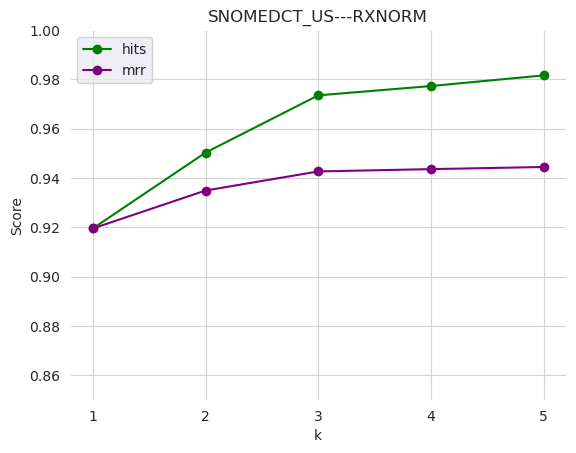

In [28]:
plot_metrics_vs_k(rxnorm_sno_res, 'RXNORM----SNOMEDCT_US')
plot_metrics_vs_k(sno_rxnorm_res, 'SNOMEDCT_US---RXNORM')

In [30]:
rxnorm_sno_res['ai_hit@1']


0.946515397082658

In [ ]:
rxnorm_sno_res['hits@1'] - rxnorm_sno_res['ai_hit@1']

In [29]:
sno_rxnorm_res['ai_hit@1']


0.9173419773095624

In [ ]:
sno_rxnorm_res['hits@1'] - sno_rxnorm_res['ai_hit@1']

## NCBI vs RXNORM

In [ ]:
ncbi_rxnorm = open_res_table('NCBI RXNORM')
rxnorm_ncbi = open_res_table('RXNORM NCBI')
print(f'num of mappings: {len(ncbi_rxnorm)}')
print(f'num of mappings: {len(rxnorm_ncbi)}')

In [ ]:
ncbi_rxnorm_res = evaluate_mapper(ncbi_rxnorm, 'RXNORM')
rxnorm_ncbi_res = evaluate_mapper(rxnorm_ncbi, 'NCBI')

In [ ]:
plot_metrics_vs_k(ncbi_rxnorm_res, 'NCBI----RXNORM')
plot_metrics_vs_k(rxnorm_ncbi_res, 'RXNORM----NCBI')

In [ ]:
ncbi_rxnorm_res['ai_hit@1']

In [ ]:
rxnorm_ncbi_res['ai_hit@1']

## LOINC vs RXNORM

In [ ]:
lnc_rxnorm = open_res_table('LNC RXNORM')
rxnorm_lnc = open_res_table('RXNORM LNC')
print(f'num of mappings: {len(lnc_rxnorm)}')
print(f'num of mappings: {len(rxnorm_lnc)}')

In [ ]:
lnc_rxnorm_res = evaluate_mapper(lnc_rxnorm, 'RXNORM')
rxnorm_lnc_res = evaluate_mapper(rxnorm_lnc, 'LNC')

In [ ]:
plot_metrics_vs_k(lnc_rxnorm_res, 'LOINC----RXNORM')
plot_metrics_vs_k(rxnorm_lnc_res, 'RXNORM----LOINC')

In [ ]:
lnc_rxnorm_res['ai_hit@1']

In [ ]:
rxnorm_lnc_res['ai_hit@1']

## LOINC vs NCBI


In [ ]:
lnc_ncbi = open_res_table('LNC NCBI')
ncbi_lnc = open_res_table('NCBI LNC')
print(f'num of mappings: {len(lnc_ncbi)}')
print(f'num of mappings: {len(ncbi_lnc)}')

In [ ]:
lnc_ncbi_res = evaluate_mapper(lnc_ncbi, 'NCBI')
ncbi_lnc_res = evaluate_mapper(ncbi_lnc, 'LNC')

In [ ]:
plot_metrics_vs_k(lnc_ncbi_res, 'LOINC----NCBI')
plot_metrics_vs_k(ncbi_lnc_res, 'NCBI----LOINC')

In [ ]:
lnc_ncbi_res['ai_hit@1']

In [ ]:
ncbi_lnc_res['ai_hit@1']

# LLMs benchmarking

In [11]:
from Evaluation.OntoMapping_benchmark.src.compute_scores import parse_to_list_of_strings

import ast
import pandas as pd
from pathlib import Path


# ---------------------------------------------------------------------------
# Parsing helpers
# ---------------------------------------------------------------------------

def parse_lnc_list(val):
    """Parse bracket-wrapped lists like '[LP66443-0, LP66443-0]' (no quotes)."""
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return []
    s = str(val).strip().strip('[]')
    return [x.strip() for x in s.split(',') if x.strip()]


def parse_py_list(val):
    """Parse Python-style string lists like \"['Alphavirus', 'Alphaviridae']\"."""
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return []
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else [result]
    except Exception:
        s = str(val).strip().strip('[]').replace("'", "").replace('"', '')
        return [x.strip() for x in s.split(',') if x.strip()]


def longest_string(lst):
    """Return the longest string in a list, or empty string if list is empty."""
    return max(lst, key=len) if lst else ''




# ---------------------------------------------------------------------------
# Evaluation logic
# ---------------------------------------------------------------------------
def classify_ai_code(ai_code, ground_truth):
    """
    Returns one of: 'correct', 'wrong', 'nan', 'review', 'empty_candidates'
    Note: 'empty_candidates' is passed in separately based on se_codes.
    """
    if pd.isna(ai_code) or str(ai_code).strip().lower() in ('', 'nan', 'none'):
        return 'nan'
    code = str(ai_code).strip()
    if 'needs_review' in code.lower() or 'needs review' in code.lower():
        return 'review'
    if code in ground_truth:
        return 'correct'
    return 'wrong'


def evaluate_dataframe(df):
    """
    Evaluates a result DataFrame and returns:
      - df_eval: original df with added evaluation columns
      - summary: dict with hits@1, accuracy, failure counts
      - failures: dict of DataFrames keyed by failure type
    """
    records = []

    for _, row in df.iterrows():
        gt = row.get('LNC_ids', '')
        ncbi_names = parse_py_list(row.get('NCBI_names', ''))
        se_codes = row.get('se_codes', '')
        se_names = parse_py_list(row.get('se_names', ''))
        ai_code = row.get('AI_code', '')

        longest_ncbi = longest_string(ncbi_names)
        empty_candidates = len(se_codes) == 0

        # hits@1: first candidate in se_codes matches ground truth
        hit1 = (not empty_candidates) and bool(se_codes) and (se_codes[0] in gt)

        # AI code classification
        if empty_candidates:
            ai_cat = classify_ai_code(ai_code, gt)
            # still classify ai_code normally; empty_candidates is a separate flag
        else:
            ai_cat = classify_ai_code(ai_code, gt)

        accurate = ai_cat == 'correct'

        # Failure category: prioritise empty_candidates if no correct AI code
        if accurate:
            fail_cat = None
        elif empty_candidates:
            fail_cat = 'empty_candidates'
        else:
            fail_cat = ai_cat  # 'wrong', 'nan', or 'review'

        records.append({
            'CUI': row.get('CUI', ''),
            'longest_NCBI_name': longest_ncbi,
            'ground_truth_LNC': gt,
            'se_codes': se_codes,
            'se_names': se_names,
            'AI_code': str(ai_code) if not pd.isna(ai_code) else '',
            'hit1': hit1,
            'accurate': accurate,
            'fail_cat': fail_cat,
        })

    df_eval = pd.DataFrame(records)
    n = len(df_eval)

    summary = {
        'n_samples': n,
        'hits_at_1': df_eval['hit1'].astype(bool).sum(),
        'hits_at_1_pct': round(100 * df_eval['hit1'].mean(), 2) if n else 0,
        'accuracy': df_eval['accurate'].sum(),
        'accuracy_pct': round(100 * df_eval['accurate'].mean(), 2) if n else 0,
        'fail_wrong': (df_eval['fail_cat'] == 'wrong').sum(),
        'fail_nan': (df_eval['fail_cat'] == 'nan').sum(),
        'fail_review': (df_eval['fail_cat'] == 'review').sum(),
        'fail_empty_candidates': (df_eval['fail_cat'] == 'empty_candidates').sum(),
    }

    failures = {
        cat: df_eval[df_eval['fail_cat'] == cat].reset_index(drop=True)
        for cat in ('wrong', 'nan', 'review', 'empty_candidates')
    }

    return df_eval, summary, failures


# ---------------------------------------------------------------------------
# Main entry point
# ---------------------------------------------------------------------------

def evaluate_llm_files(file_paths):
    """
    Evaluate one or more LLM result .xlsx files.

    Parameters
    ----------
    file_paths : list of str or Path
        Paths to the .csv files. One file per LLM.

    Returns
    -------
    results : dict
        Keys are file names (without extension). Values are dicts with:
          'summary'  : dict of scalar metrics
          'eval_df'  : full evaluated DataFrame
          'failures' : dict of failure DataFrames by category
    """
    results = {}

    for path in file_paths:
        path = Path(path)
        name = path.stem

        df = pd.read_csv(path).drop_duplicates(subset = 'CUI')
        df[f'LNC_ids'] = df[f'LNC_ids'].apply(lambda x: parse_to_list_of_strings(x))
        df['se_codes'] = df['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
        df['AI_code'] =  df['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)

        df_eval, summary, failures = evaluate_dataframe(df)

        results[name] = {
            'summary': summary,
            'eval_df': df_eval,
            'failures': failures,
        }

        print(f"\n{'='*50}")
        print(f"LLM: {name}")
        print(f"{'='*50}")
        print(f"  Samples     : {summary['n_samples']}")
        print(f"  Hits@1      : {summary['hits_at_1']} / {summary['n_samples']}  ({summary['hits_at_1_pct']}%)")
        print(f"  Accuracy    : {summary['accuracy']} / {summary['n_samples']}  ({summary['accuracy_pct']}%)")
        print(f"\n  Failures breakdown:")
        print(f"    Wrong code       : {summary['fail_wrong']}")
        print(f"    NaN              : {summary['fail_nan']}")
        print(f"    Needs_Review     : {summary['fail_review']}")
        print(f"    Empty candidates : {summary['fail_empty_candidates']}")

        for cat, fdf in failures.items():
            if not fdf.empty:
                print(f"\n  --- {cat.upper()} failures ---")
                print(fdf[['CUI', 'longest_NCBI_name', 'ground_truth_LNC', 'AI_code', 'se_codes']].to_string(index=False))

    return results


# ---------------------------------------------------------------------------
# Comparison helper
# ---------------------------------------------------------------------------

def compare_llms(results):
    """
    Build a summary comparison DataFrame across all LLMs.

    Parameters
    ----------
    results : dict  (output of evaluate_llm_files)

    Returns
    -------
    pd.DataFrame with one row per LLM
    """
    rows = []
    for name, res in results.items():
        s = res['summary']
        rows.append({
            'LLM': name,
            'n_samples': s['n_samples'],
            'sm_accuracy': s['hits_at_1'],
            'sm_accuracy (%)': s['hits_at_1_pct'],
            'llm_accuracy': s['accuracy'],
            'llm_accuracy (%)': s['accuracy_pct'],
            'fail_wrong': s['fail_wrong'],
            'fail_nan': s['fail_nan'],
            'fail_review': s['fail_review'],
            'fail_empty_candidates': s['fail_empty_candidates'],
        })
    return pd.DataFrame(rows).set_index('LLM')


def read_res_file(x: str, source_onto: str, target_onto:str) -> pd.DataFrame:
    df = pd.read_csv(f'results/OntoMapping_benchmark/trial_2_k_50/selector_output_{x}_25_{source_onto}_{target_onto}.csv')
    df[f'{target_onto}_ids'] = df[f'{target_onto}_ids'].apply(lambda x: parse_to_list_of_strings(x))
    df['se_codes'] = df['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
    df['AI_code'] = df['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)
    return df






In [4]:
with open('results/OntoMapping_benchmark/llms_benchmarking/computational_time_selector.txt', 'r') as file:
    time_selector = file.read()

time_selector

'granite4:latest: 00:03:57 \ngranite4:latest: 00:03:57 \ngranite4:latest: 00:05:09 \n'

In [135]:
import time

formatted_time = time.strftime("%H:%M:%S", time.gmtime(1942.192))
formatted_time

'00:32:22'

### GPT-OSS

In [6]:
gpt_df = pd.read_csv(f'results/OntoMapping_benchmark/llms_benchmarking/selector_output_gpt-oss:20b_25_NCBI_LNC.csv')
gpt_df[f'LNC_ids'] = gpt_df[f'LNC_ids'].apply(lambda x: parse_to_list_of_strings(x))
gpt_df['se_codes'] = gpt_df['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
gpt_df['AI_code'] =  gpt_df['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)

gpt_df.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"['Alphavirus', 'Alphaviridae']","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,Alphavirus
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"['Canis familiaris', 'Canis borealis', 'Canis ...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,Canis familiaris native (nCan f) 1
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","['Enterobacter', 'Cloaca', '""Aerobacter"" Horma...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",LA21491-8,Enterobacter species
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"['Bacteroides fragilis', 'Bacteroides fragilis...","[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,Bacteroides fragilis
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","['Corynebacterium diphtheriae', 'Bacillus diph...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,Corynebacterium diphtheriae


In [16]:
gpt_df[gpt_df['CUI'] in gpt_df['CUI'].unique()]


KeyError: True

In [12]:
len(gpt_df)

349

In [7]:
gpt_df['AI_code'].value_counts()[:10]

AI_code
Needs_Review    43
LA34296-6        2
LP19253-1        2
MTHU070926       2
LP19933-8        2
LA34281-8        2
MTHU010891       2
MTHU071802       2
LP16673-3        2
LP31630-4        2
Name: count, dtype: int64

In [10]:
gpt_df['AI_code'].isna().sum()

0

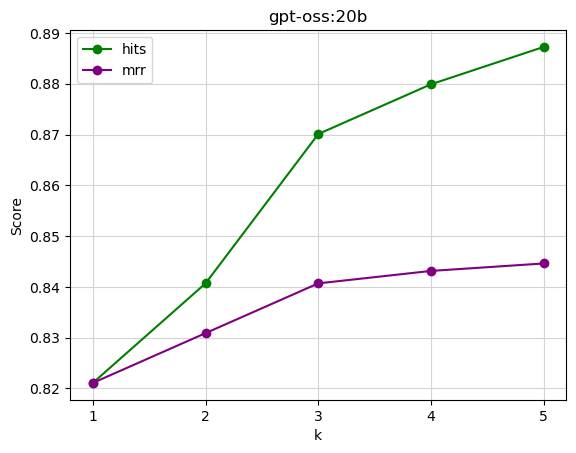

In [32]:
gpt_res = evaluate_mapper(gpt_df, 'LNC')
plot_metrics_vs_k(gpt_res, 'gpt-oss:20b')

In [33]:
gpt_res['ai_hit@1']


0.7696078431372549

### GRANITE 4

In [6]:
granite_df_50 = read_res_file('granite4:latest', 'NCBI', 'LNC')
granite_df_50.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"['Alphavirus', 'Alphaviridae']","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,Alphavirus
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"['Canis familiaris', 'Canis borealis', 'Canis ...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,Canis familiaris native (nCan f) 1
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","['Enterobacter', 'Cloaca', '""Aerobacter"" Horma...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",None,NaN
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"['Bacteroides fragilis', 'Bacteroides fragilis...","[LP16785-5, LP16785-5, MTHU014763, LP37211-7, ...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,Bacteroides fragilis
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","['Corynebacterium diphtheriae', 'Bacillus diph...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,Corynebacterium diphtheriae


In [12]:
gpt_120_50 = read_res_file('gpt-oss:120b', 'NCBI', 'LNC')
gpt_eval, gpt_summary, gpt_failures = evaluate_dataframe(gpt_120_50)

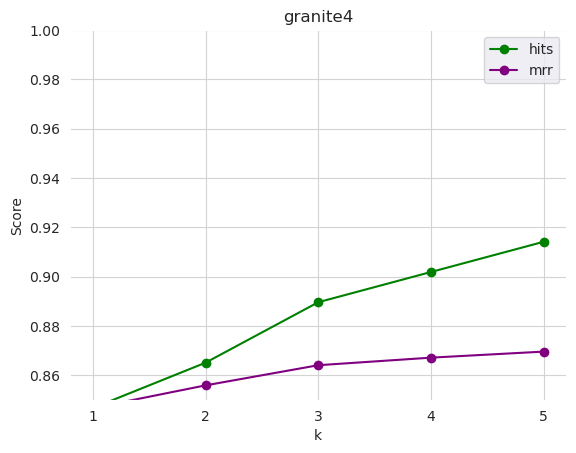

In [8]:
granite_eval, granite_summary, granite_failures = evaluate_dataframe(granite_df_50)
granite_res = evaluate_mapper(granite_df_50, 'LNC')
plot_metrics_vs_k(granite_res, 'granite4')

In [13]:
gpt_failures['wrong']


,CUI,longest_NCBI_name,ground_truth_LNC,se_codes,se_names,AI_code,hit1,accurate,fail_cat
0,C0012984,Canis lupus familiaris,[LA14178-0],"[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","[Canis familiaris native (nCan f) 1, Brucella ...",LP183663-6,False,False,wrong
1,C0014344,"""Aerobacter"" Hormaeche and Edwards 1958","[LP105046-9, LA21491-8]","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","[Aeromonas sp, Aeromonas sp, Aeromonas sp, Cit...",LP102525-5,False,False,wrong
2,C0001699,'Klebsiella aerogenes' (Kruse) Taylor et al. 1956,"[LP102544-6, LA21336-5]","[LP309965-4, LP309965-4, LP102525-5, LA28469-7...","[Klebsiella aerogenes, Klebsiella aerogenes, E...",LP309965-4,False,False,wrong
3,C0004589,Bacillus cereus var. anthracis,"[LP16672-5, MTHU002712, LA29437-3, LG41626-9]","[LP16672-5, LG41626-9, LA29437-3, MTHU002712, ...","[Bacillus anthracis, Bacillus anthracis, Bacil...",LP19584-9,True,False,wrong
4,C0014047,Japanese encephalitis (JE) virus,[LP17702-9],"[LA31148-2, LP17702-9, LP17702-9, LA10480-4, M...","[Japanese encephalitis virus, Japanese encepha...",LA31148-2,False,False,wrong
5,C0018481,Bacillus ulceris cancrosi,"[LP15183-4, MTHU001855, LG41624-4]","[LP434649-2, LP434649-2, MTHU069952, LP438605-...","[Mycobacterium ulcerans, Mycobacterium ulceran...",MTHU069952,False,False,wrong
6,C0023273,Leishmania (Leishmania) donovani,[LA28383-0],"[LP18310-0, LP18310-0, LA28383-0, LP201736-8, ...","[Leishmania donovani, Leishmania donovani, Lei...",LP18310-0,False,False,wrong
7,C0018019,Capra aegagrus hircus,[LA31039-3],"[LP432550-4, LA31039-3, MTHU068435, MTHU068435...","[Capra aegagrus hircus, Goat, Capra aegagrus h...",LP432550-4,False,False,wrong
8,C0085483,the Ballerup group of bacteria,"[LA29360-7, LP429501-2]","[LP30576-0, LA30664-9, LP30576-0, LP36837-0, L...","[Pseudomonas sp, Pseudomonas sp, Pseudomonas s...",LP343404-2,False,False,wrong
9,C0085479,Fusobacterium plauti-vincenti,[LP411482-5],"[LP411482-5, LP411482-5, LP441886-1, LP441886-...","[Fusobacterium nucleatum, Fusobacterium nuclea...",LP441886-1,True,False,wrong


In [14]:
with open('RAG_mapper/prompts/system_instructions_evaluator.md') as f:
    system_prompt = f.read()

with open('RAG_mapper/prompts/human_prompt_evaluator.md') as f:
    human_template = f.read()

In [52]:
granite_df = read_res_file('granite4:latest', 'NCBI', 'LNC')
granite_df.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"['Alphavirus', 'Alphaviridae']","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,Alphavirus
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"['Canis familiaris', 'Canis borealis', 'Canis ...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,Canis familiaris native (nCan f)
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","['Enterobacter', 'Cloaca', '""Aerobacter"" Horma...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",None,NaN
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"['Bacteroides fragilis', 'Bacteroides fragilis...","[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,Bacteroides fragilis
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","['Corynebacterium diphtheriae', 'Bacillus diph...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,Corynebacterium diphtheriae


,CUI,longest_NCBI_name,ground_truth_LNC,se_codes,AI_code,hit1,accurate,fail_cat
0,C0002331,Alphaviridae,[LP66443-0],"[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...",LP66443-0,True,True,None
1,C0012984,Canis lupus familiaris,[LA14178-0],"[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...",LP183663-6,False,False,wrong
2,C0014344,"""Aerobacter"" Hormaeche and Edwards 1958","[LP105046-9, LA21491-8]","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...",,False,False,nan
3,C0004663,Bacteroides fragilis (Veillon and Zuber 1898) ...,[LP16785-5],"[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...",LP16785-5,True,True,None
4,C0010150,Corynebacterium diphtheriae,"[LP16683-2, MTHU006922, LG41614-5]","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...",LP16683-2,True,True,None


In [56]:
granite_eval, granite_summary, granite_failures = evaluate_dataframe(granite_df)

In [64]:
granite_df.iloc[2, :]


Unnamed: 0                                                   82
CUI                                                    C0014344
LNC_ids                                 [LP105046-9, LA21491-8]
NCBI_ids                                  ['547', '547', '547']
LNC_names           ['Enterobacter sp', 'Enterobacter species']
NCBI_names    ['Enterobacter', 'Cloaca', '"Aerobacter" Horma...
se_codes      [MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...
se_names      ['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...
AI_code                                                    None
AI_name                                                     NaN
Name: 2, dtype: object

In [70]:
granite_df['AI_code']

0       LP66443-0
1      LP183663-6
2            None
3       LP16785-5
4       LP16683-2
          ...    
158    LP441919-0
159     LG41646-7
160     LP17625-2
161    LP419926-3
162    LP441913-3
Name: AI_code, Length: 163, dtype: object

In [72]:
granite_df['AI_code'].isna().sum()


4

In [9]:
granite_df = pd.read_csv(f'results/OntoMapping_benchmark/llms_benchmarking/selector_output_granite4:latest_25_NCBI_LNC.csv')
granite_df[f'LNC_ids'] = granite_df[f'LNC_ids'].apply(lambda x: parse_to_list_of_strings(x))
granite_df['se_codes'] = granite_df['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
granite_df['AI_code'] =  granite_df['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)

granite_df.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"['Alphavirus', 'Alphaviridae']","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,Alphavirus
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"['Canis familiaris', 'Canis borealis', 'Canis ...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,Canis familiaris native (nCan f)
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","['Enterobacter', 'Cloaca', '""Aerobacter"" Horma...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",None,NaN
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"['Bacteroides fragilis', 'Bacteroides fragilis...","[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,Bacteroides fragilis
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","['Corynebacterium diphtheriae', 'Bacillus diph...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,Corynebacterium diphtheriae


In [10]:
len(granite_df)

408

In [34]:
granite_df['AI_code'].value_counts()[:10]

AI_code
LP14087-8     3
LP19253-1     2
LP16660-0     2
LP269093-3    2
LP19933-8     2
LP268997-6    2
LP16720-2     2
LP19887-6     2
LA34281-8     2
LP310485-0    2
Name: count, dtype: int64

In [27]:
granite_df['AI_code'].isna().sum()

7

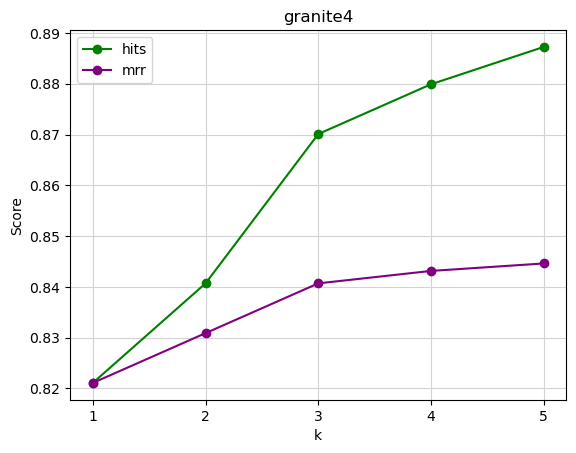

In [10]:
granite_res = evaluate_mapper(granite_df, 'LNC')
plot_metrics_vs_k(granite_res, 'granite4')

In [11]:
granite_res['ai_hit@1']

0.8112745098039216

### QWEN3.5

#### 4B parameters

In [12]:
qwen_df = pd.read_csv(f'results/OntoMapping_benchmark/llms_benchmarking/selector_output_qwen3.5:4b_25_NCBI_LNC.csv')
qwen_df[f'LNC_ids'] = qwen_df[f'LNC_ids'].apply(lambda x: parse_to_list_of_strings(x))
qwen_df['se_codes'] = qwen_df['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
qwen_df['AI_code'] =  qwen_df['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)

qwen_df.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"['Alphavirus', 'Alphaviridae']","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,NaN
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"['Canis familiaris', 'Canis borealis', 'Canis ...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,NaN
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","['Enterobacter', 'Cloaca', '""Aerobacter"" Horma...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",None,NaN
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"['Bacteroides fragilis', 'Bacteroides fragilis...","[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,NaN
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","['Corynebacterium diphtheriae', 'Bacillus diph...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,NaN


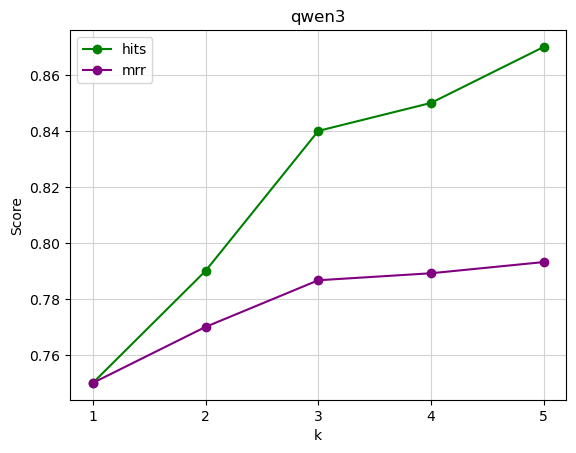

In [14]:
qwen_res = evaluate_mapper(qwen_df, 'LNC')
plot_metrics_vs_k(qwen_res, 'qwen3.5')

In [15]:
qwen_res['ai_hit@1']

0.68

#### 27B parameters

In [6]:
qwen_df_27 = pd.read_csv(f'results/OntoMapping_benchmark/llms_benchmarking/selector_output_qwen3.5:27b_25_NCBI_LNC.csv')
qwen_df_27[f'LNC_ids'] = qwen_df_27[f'LNC_ids'].apply(lambda x: parse_to_list_of_strings(x))
qwen_df_27['se_codes'] = qwen_df_27['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
qwen_df_27['AI_code'] =  qwen_df_27['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)

qwen_df_27.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"['Alphavirus', 'Alphaviridae']","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,Alphavirus
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"['Canis familiaris', 'Canis borealis', 'Canis ...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,Canis familiaris native (nCan f) 1
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","['Enterobacter', 'Cloaca', '""Aerobacter"" Horma...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",None,NaN
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"['Bacteroides fragilis', 'Bacteroides fragilis...","[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,Bacteroides fragilis
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","['Corynebacterium diphtheriae', 'Bacillus diph...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,Corynebacterium diphtheriae


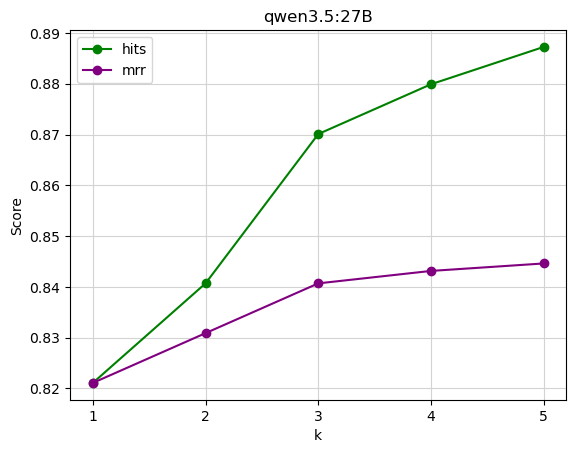

In [7]:
qwen_res_27 = evaluate_mapper(qwen_df_27, 'LNC')
plot_metrics_vs_k(qwen_res_27, 'qwen3.5:27B')

In [8]:
qwen_res_27['ai_hit@1']

0.5759803921568627

#### 35B parameters

In [9]:
qwen_df_35 = pd.read_csv(f'results/OntoMapping_benchmark/llms_benchmarking/selector_output_qwen3.5:35b_25_NCBI_LNC.csv')
qwen_df_35[f'LNC_ids'] = qwen_df_35[f'LNC_ids'].apply(lambda x: parse_to_list_of_strings(x))
qwen_df_35['se_codes'] = qwen_df_35['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
qwen_df_35['AI_code'] =  qwen_df_35['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)

qwen_df_35.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"['Alphavirus', 'Alphaviridae']","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,Alphavirus
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"['Canis familiaris', 'Canis borealis', 'Canis ...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,Canis familiaris native (nCan f) 1
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","['Enterobacter', 'Cloaca', '""Aerobacter"" Horma...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",LA21490-0,Citrobacter species
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"['Bacteroides fragilis', 'Bacteroides fragilis...","[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,Bacteroides fragilis
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","['Corynebacterium diphtheriae', 'Bacillus diph...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,Corynebacterium diphtheriae


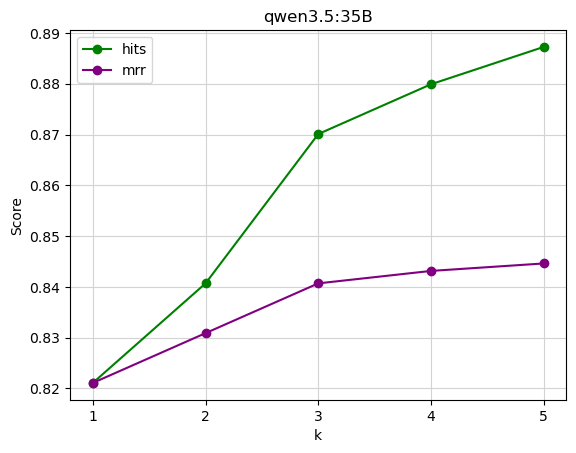

In [10]:
qwen_res_35 = evaluate_mapper(qwen_df_35, 'LNC')
plot_metrics_vs_k(qwen_res_35, 'qwen3.5:35B')

In [11]:
qwen_res_35['ai_hit@1']

0.8112745098039216

### Gemma4

In [74]:
gemma_df = read_res_file('gemma4:latest', 'NCBI', 'LNC')

gemma_df.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"['Alphavirus', 'Alphaviridae']","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,Alphavirus
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"['Canis familiaris', 'Canis borealis', 'Canis ...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,Canis familiaris native (nCan f) 1
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","['Enterobacter', 'Cloaca', '""Aerobacter"" Horma...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",MTHU014226,Aeromonas sp
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"['Bacteroides fragilis', 'Bacteroides fragilis...","[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,Bacteroides fragilis
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","['Corynebacterium diphtheriae', 'Bacillus diph...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,Corynebacterium diphtheriae


In [75]:
gemma_eval, gemma_summary, gemma_failures = evaluate_dataframe(gemma_df)

In [79]:
gemma_eval.columns


Index(['CUI', 'longest_NCBI_name', 'ground_truth_LNC', 'se_codes', 'AI_code',
       'hit1', 'accurate', 'fail_cat'],
      dtype='object')

In [81]:
gemma_summary

{'n_samples': 163,
 'hits_at_1': 138,
 'hits_at_1_pct': 84.66,
 'accuracy': 135,
 'accuracy_pct': 82.82,
 'fail_wrong': 22,
 'fail_nan': 0,
 'fail_review': 6,
 'fail_empty_candidates': 0}

In [83]:
gemma_failures.keys()

dict_keys(['wrong', 'nan', 'review', 'empty_candidates'])

In [41]:
gemma_df['longest_NCBI_name'] = gemma_df['NCBI_names'].apply(lambda x: longest_string(x))
gemma_df.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name,longest_NCBI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"[Alphavirus, Alphaviridae]","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,Alphavirus,Alphaviridae
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"[Canis familiaris, Canis borealis, Canis lupus...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,Canis familiaris native (nCan f) 1,Canis lupus familiaris
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","[Enterobacter, Cloaca, ""Aerobacter"" Hormaeche ...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",MTHU014226,Aeromonas sp,"""Aerobacter"" Hormaeche and Edwards 1958"
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"[Bacteroides fragilis, Bacteroides fragilis (V...","[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,Bacteroides fragilis,Bacteroides fragilis (Veillon and Zuber 1898) ...
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","[Corynebacterium diphtheriae, Bacillus diphthe...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,Corynebacterium diphtheriae,Corynebacterium diphtheriae


In [43]:
err1 = gemma_df[gemma_df['longest_NCBI_name']=='Pasteurella pseudotuberculosis']
err1

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name,longest_NCBI_name
53,260,C0043409,[LP16782-2],"['633', '633', '633', '633', '633', '633']",['Yersinia pseudotuberculosis'],"[Yersinia pseudotuberculosis, Pasteurella pseu...","[LP16782-2, LP16782-2, MTHU069951, LP438604-3,...","['Yersinia pseudotuberculosis', 'Yersinia pseu...",Needs_Review,NaN,Pasteurella pseudotuberculosis


In [44]:
err2 = gemma_df[gemma_df['longest_NCBI_name']=='Actinomyces violaceus subsp. brasiliensis']
err2

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name,longest_NCBI_name
80,408,C0317896,[LA19290-8],"['37326', '37326', '37326', '37326', '37326', ...",['Nocardia brasiliensis'],"[Nocardia brasiliensis, Actinomyces brasiliens...","[LA19290-8, LP36568-1, LA19188-4, LP36568-1, L...","['Nocardia brasiliensis', 'Actinomyces israeli...",Needs_Review,NaN,Actinomyces violaceus subsp. brasiliensis


In [33]:
df_eval[df_eval['AI_code']=='Needs_Review']

,CUI,longest_NCBI_name,ground_truth_LNC,se_codes,AI_code,hit1,accurate,fail_cat
53,C0043409,Pasteurella pseudotuberculosis,[LP16782-2],"[LP16782-2, LP16782-2, MTHU069951, LP438604-3,...",Needs_Review,True,False,review
62,C0317716,Murraya grayi subsp. murrayi,[LA29382-1],[Needs_Review],Needs_Review,False,False,review
80,C0317896,Actinomyces violaceus subsp. brasiliensis,[LA19290-8],"[LA19290-8, LP36568-1, LA19188-4, LP36568-1, L...",Needs_Review,True,False,review
92,C0319898,"Debaryomyces hansenii (Zopf) Lodder & Kreger, ...","[LA28242-8, LP310485-0]","[LP441925-7, LP441925-7, LP310485-0, LP310485-...",Needs_Review,False,False,review
111,C0445780,Aeromonas hybridization group 12,[LA34295-8],"[LA34296-6, LA34278-4, LA34281-8, LP434583-3, ...",Needs_Review,False,False,review
127,C0999806,Alphapapillomavirus 9,[LP18037-9],"[LP102530-5, LP102530-5, LP102538-8, LP102538-...",Needs_Review,False,False,review


In [31]:
failures['review']

,CUI,longest_NCBI_name,ground_truth_LNC,se_codes,AI_code,hit1,accurate,fail_cat
0,C0043409,Pasteurella pseudotuberculosis,[LP16782-2],"[LP16782-2, LP16782-2, MTHU069951, LP438604-3,...",Needs_Review,True,False,review
1,C0317716,Murraya grayi subsp. murrayi,[LA29382-1],[Needs_Review],Needs_Review,False,False,review
2,C0317896,Actinomyces violaceus subsp. brasiliensis,[LA19290-8],"[LA19290-8, LP36568-1, LA19188-4, LP36568-1, L...",Needs_Review,True,False,review
3,C0319898,"Debaryomyces hansenii (Zopf) Lodder & Kreger, ...","[LA28242-8, LP310485-0]","[LP441925-7, LP441925-7, LP310485-0, LP310485-...",Needs_Review,False,False,review
4,C0445780,Aeromonas hybridization group 12,[LA34295-8],"[LA34296-6, LA34278-4, LA34281-8, LP434583-3, ...",Needs_Review,False,False,review
5,C0999806,Alphapapillomavirus 9,[LP18037-9],"[LP102530-5, LP102530-5, LP102538-8, LP102538-...",Needs_Review,False,False,review


### Best selector

In [ ]:
llm_models = ['gpt-oss:20b',  'granite4:latest', 'qwen3.5:4b', 'qwen3.5:35b', 'gemma4:latest']


In [86]:
eval_dict = {llm: evaluate_dataframe(read_res_file(llm, 'NCBI', 'LNC'))[0] for llm in llm_models}
eval_dict[llm_models[0]]

,CUI,longest_NCBI_name,ground_truth_LNC,se_codes,AI_code,hit1,accurate,fail_cat
0,C0002331,Alphaviridae,[LP66443-0],"[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...",LP66443-0,True,True,None
1,C0012984,Canis lupus familiaris,[LA14178-0],"[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...",LP183663-6,False,False,wrong
2,C0014344,"""Aerobacter"" Hormaeche and Edwards 1958","[LP105046-9, LA21491-8]","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...",LA21491-8,False,True,None
3,C0004663,Bacteroides fragilis (Veillon and Zuber 1898) ...,[LP16785-5],"[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...",LP16785-5,True,True,None
4,C0010150,Corynebacterium diphtheriae,"[LP16683-2, MTHU006922, LG41614-5]","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...",LP16683-2,True,True,None
...,...,...,...,...,...,...,...,...
158,C1478201,"Nakaseomyces bracarensis (A. Correia, P. Samp....","[LA28230-3, LP441919-0]","[LP441919-0, LP441919-0, LA28230-3, LP441920-8...",LP441919-0,True,True,None
159,C1744526,Cryptosporidium,"[MTHU008557, LA26116-6, LP268981-0, LG41646-7,...","[LG41646-7, LP268981-0, LA26116-6, MTHU008557,...",LG41646-7,True,True,None
160,C4551821,Sphacelotheca cruenta,"[LP17625-2, LP17625-2]","[LP17625-2, LP17625-2, LP39803-9, LP39803-9, M...",LP17625-2,True,True,None
161,C4760374,Eurotium repens var. pseudoglaucum,[LP419926-3],"[LP419926-3, LP419926-3, LP19399-2, LP113696-1...",LP419926-3,True,True,None


In [35]:
for i, (_, row) in enumerate(gpt_df.iterrows()):
    gt = row.get('LNC_ids', '')
    se_codes = row.get('se_codes', '')

    # --- ADD THIS DEBUG BLOCK ---
    if i < 5:
        print(f"\n--- Row {i} Debug ---")
        print(f"GT Type: {type(gt)} | Value: {gt}")
        print(f"SE Type: {type(se_codes)} | Value: {se_codes}")
        if len(se_codes) > 0:
            print(f"SE[0] Type: {type(se_codes[0])} | Value: {se_codes[0]}")
            print(f"Comparison: Does {se_codes[0]} exist in {gt}? -> {se_codes[0] in gt}")
    # --- END DEBUG BLOCK ---


--- Row 0 Debug ---
GT Type: <class 'list'> | Value: ['LP66443-0']
SE Type: <class 'list'> | Value: ['LP66443-0', 'LP66443-0', 'LP66444-8', 'MTHU027941', 'LP66444-8']
SE[0] Type: <class 'str'> | Value: LP66443-0
Comparison: Does LP66443-0 exist in ['LP66443-0']? -> True

--- Row 1 Debug ---
GT Type: <class 'list'> | Value: ['LA14178-0']
SE Type: <class 'list'> | Value: ['LP183663-6', 'LP14092-8', 'LA19198-3', 'LP14092-8', 'LP28645-7']
SE[0] Type: <class 'str'> | Value: LP183663-6
Comparison: Does LP183663-6 exist in ['LA14178-0']? -> False

--- Row 2 Debug ---
GT Type: <class 'list'> | Value: ['LP105046-9', 'LA21491-8']
SE Type: <class 'list'> | Value: ['MTHU014226', 'LP28822-2', 'LP28822-2', 'LA21490-0', 'LA21491-8']
SE[0] Type: <class 'str'> | Value: MTHU014226
Comparison: Does MTHU014226 exist in ['LP105046-9', 'LA21491-8']? -> False

--- Row 3 Debug ---
GT Type: <class 'list'> | Value: ['LP16785-5']
SE Type: <class 'list'> | Value: ['LP16785-5', 'LP16785-5', 'MTHU014763', 'MTHU014

In [2]:
df_eval, summary, failures = evaluate_dataframe(gpt_df)

NameError: name 'gpt_df' is not defined

In [41]:
df_eval


,CUI,longest_NCBI_name,ground_truth_LNC,se_codes,AI_code,hit1,accurate,fail_cat
0,C0002331,Alphaviridae,[LP66443-0],"[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...",LP66443-0,True,True,None
1,C0012984,Canis lupus familiaris,[LA14178-0],"[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...",LP183663-6,False,False,wrong
2,C0014344,"""Aerobacter"" Hormaeche and Edwards 1958","[LP105046-9, LA21491-8]","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...",LA21491-8,False,True,None
3,C0004663,Bacteroides fragilis (Veillon and Zuber 1898) ...,[LP16785-5],"[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...",LP16785-5,True,True,None
4,C0010150,Corynebacterium diphtheriae,"[LP16683-2, MTHU006922, LG41614-5]","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...",LP16683-2,True,True,None
...,...,...,...,...,...,...,...,...
403,C3627315,Kobuvirus cebes,[LP267181-8],[Needs_Review],Needs_Review,False,False,review
404,C4348979,Ambrosia deltoidea,"[LP281369-1, LP281369-1]","[LP281369-1, LP281369-1, MTHU061986, LP281378-...",LP281369-1,True,True,None
405,C4721546,Influenza C like virus C/OK,[LP247860-2],"[LP16718-6, LP16718-6, MTHU014060, LG32772-2, ...",LP16718-6,False,False,wrong
406,C4573175,"Pleospora betae (Berl.) Nevod., 1915",[LP17051-1],"[LP17051-1, LP17051-1, LP147834-8, MTHU022814,...",LP17051-1,True,True,None


In [46]:
summary

{'n_samples': 408,
 'hits_at_1': 335,
 'hits_at_1_pct': 82.11,
 'accuracy': 314,
 'accuracy_pct': 76.96,
 'fail_wrong': 51,
 'fail_nan': 0,
 'fail_review': 43,
 'fail_empty_candidates': 0}

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_llm_comparison(comparison_df, model_names=None, filename = 'supervisor_llm/llms_comparison.png'):
    """
    Plots LLM benchmarking results.

    Parameters:
    - comparison_df: The summary DataFrame
    - model_names: List of strings to use as X-axis labels (optional)
    """
    # Create a copy so we don't modify the original data outside the function
    df = comparison_df.copy()

    # MANUALLY SET NAMES
    if model_names and len(model_names) == len(df):
        df.index = model_names
    else:
        # Fallback to cleaning file names if manual names aren't provided or don't match
        from pathlib import Path
        df.index = [Path(str(i)).stem for i in df.index]

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- Plot 1: Accuracy & Hits@1 ---
    metrics_df = df[['sm_accuracy (%)', 'llm_accuracy (%)']].reset_index().rename(columns={'index': 'LLM'})
    metrics_df = metrics_df.melt(id_vars='LLM', var_name='Metric', value_name='Percentage')

    sns.barplot(ax=axes[0], data=metrics_df, x='LLM', y='Percentage', hue='Metric', palette='colorblind')
    axes[0].set_title('LLM Accuracy vs. Retrieval (Hits@1)', fontsize=14, fontweight='bold')
    axes[0].set_ylim(0, 115)
    axes[0].set_xlabel('')

    # Add labels on top of bars
    for p in axes[0].patches:
        axes[0].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8),
                         textcoords='offset points', fontsize=9)

    # --- Plot 2: Failure Analysis ---
    failure_map = {
        'fail_wrong': 'Wrong Code',
        'fail_nan': 'NaN/Empty',
        'fail_review': 'Needs Review',
        'fail_empty_candidates': 'No Candidates'
    }
    fail_df = df[['fail_wrong', 'fail_nan', 'fail_review', 'fail_empty_candidates']].rename(columns=failure_map)

    fail_df.plot(kind='bar', stacked=True, ax=axes[1], colormap='magma', edgecolor='white')
    axes[1].set_title('Breakdown of Errors', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Samples')
    axes[1].set_xlabel('')
    axes[1].legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(f'results/OntoMapping_benchmark/llms_benchmarking/{filename}', dpi=300, facecolor= None, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

def plot_llm_intervention_analysis(eval_dict, filename="supervisor_llm/llm_safety_benchmark.png"):
    """
    eval_dict: dict where key is model name (str) and value is df_eval (DataFrame)
    filename: the name of the file to save
    """
    analysis_results = []

    for model_name, df in eval_dict.items():
        # 1. Filter for cases where Retrieval failed (Hit@1 is False)
        retrieval_fails = df[df['hit1'] == False]
        total_fails = len(retrieval_fails)

        if total_fails == 0:
            continue

        # 2. Calculate Conditional Metrics
        recovery = len(retrieval_fails[retrieval_fails['accurate'] == True])
        safety = len(retrieval_fails[retrieval_fails['fail_cat'] == 'review'])
        hazard = total_fails - recovery - safety

        analysis_results.append({
            'LLM': model_name,
            'Recovery (Improved Search)': (recovery / total_fails) * 100,
            'Safety (Needs_Review)': (safety / total_fails) * 100,
            'Hazard (Wrong AI Code)': (hazard / total_fails) * 100
        })

    df_plot = pd.DataFrame(analysis_results).set_index('LLM')

    # Plotting
    fig, ax = plt.subplots(figsize=(9, 6), facecolor='white') # Set figure background

    df_plot.plot(kind='barh', stacked=True, ax=ax,
                 color=['#34A853', '#FBBC05', '#EA4335'])

    ax.set_title('When the semantic mapper FAILS...', fontsize=14, pad=20)
    ax.set_xlabel('Retrieval failures')
    ax.set_xlim(0, 100)
    ax.legend(title="AI Outcome", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Text labels
    for n in range(len(df_plot)):
        cumulative_x = 0
        for col in df_plot.columns:
            val = df_plot.iloc[n][col]
            if val > 5:
                ax.text(cumulative_x + val/2, n, f'{val:.1f}%',
                        va='center', ha='center', fontweight='bold',
                        color='white' if col != 'Safety (Needs_Review)' else 'black')
            cumulative_x += val

    plt.tight_layout()

    # --- The Save Line ---
    # facecolor='white' ensures the exported PNG isn't transparent
    # bbox_inches='tight' ensures the legend isn't cut off
    plt.savefig(f'results/OntoMapping_benchmark/llms_benchmarking/{filename}', dpi=300, facecolor='white', bbox_inches='tight')

    plt.show()


def plot_llm_degradation_analysis(eval_dict, filename="supervisor_llm/llm_degradation_analysis.png"):

    """
    eval_dict: dict {model_name: df_eval}
    Visualizes why LLMs fail when the search engine was actually correct.
    """
    degradation_results = []

    for model_name, df in eval_dict.items():
        # 1. Focus ONLY on samples where the Search Engine was correct
        se_correct = df[df['hit1'] == True]
        total_se_correct = len(se_correct)

        if total_se_correct == 0:
            continue

        # 2. Categorize what the LLM did with these "perfect" inputs
        retained = len(se_correct[se_correct['accurate'] == True])
        too_cautious = len(se_correct[se_correct['fail_cat'] == 'review'])
        logic_error = len(se_correct[se_correct['fail_cat'] == 'wrong'])
        other_fail = total_se_correct - retained - too_cautious - logic_error

        degradation_results.append({
            'LLM': model_name,
            'Correctly Retained': (retained / total_se_correct) * 100,
            'Degradation: Too Cautious (Review)': (too_cautious / total_se_correct) * 100,
            'Degradation: Logic Error (Wrong)': (logic_error / total_se_correct) * 100
        })

    df_plot = pd.DataFrame(degradation_results).set_index('LLM')

    # Plotting
    fig, ax = plt.subplots(figsize=(9, 6), facecolor='white')

    # Using shades of Blue for success and Warmer tones for degradation
    df_plot.plot(kind='barh', stacked=True, ax=ax,
                 color=['#4285F4', '#FFBB00', '#D93025'])

    ax.set_title('When the semantic mapper SUCCEEDS...', fontsize=14, pad=20)
    ax.set_xlabel('Retrieval success')
    ax.set_xlim(0, 100)
    ax.legend(title="AI Response", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adding data labels
    for n in range(len(df_plot)):
        cum_x = 0
        for col in df_plot.columns:
            val = df_plot.iloc[n][col]
            if val > 3:
                ax.text(cum_x + val/2, n, f'{val:.1f}%',
                        va='center', ha='center', fontweight='bold',
                        color='white' if col != 'Degradation: Too Cautious (Review)' else 'black')
            cum_x += val

    plt.tight_layout()
    plt.savefig(f'results/OntoMapping_benchmark/llms_benchmarking/{filename}', dpi=300, facecolor='white', bbox_inches='tight')
    plt.show()





In [1]:
granite_failures

NameError: name 'granite_failures' is not defined

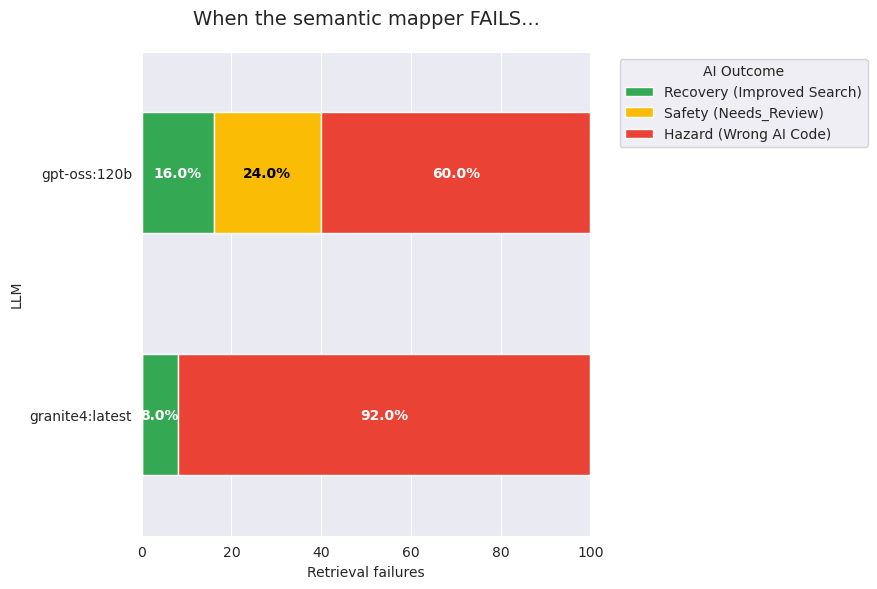

In [14]:
eval_50_dict = {'granite4:latest': granite_eval, 'gpt-oss:120b':gpt_eval }
plot_llm_intervention_analysis(eval_50_dict)

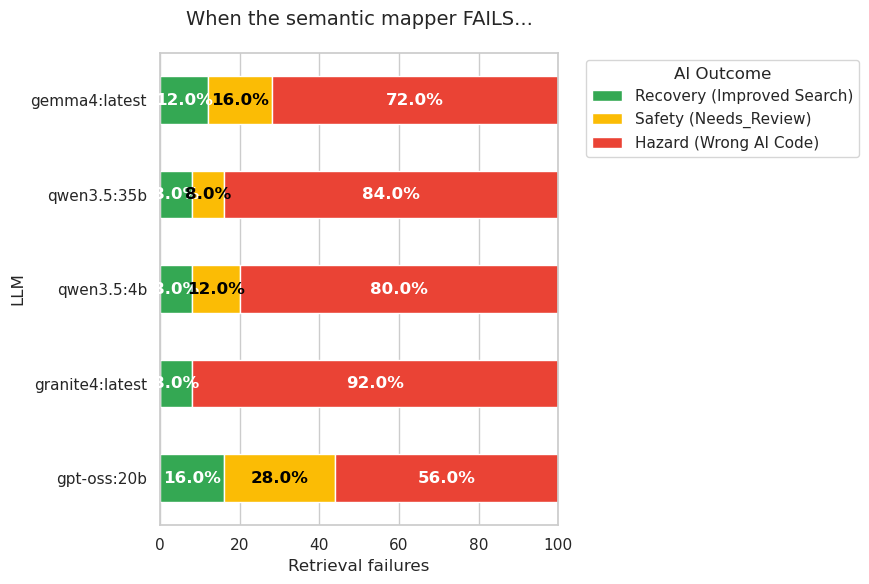

In [112]:
plot_llm_intervention_analysis(eval_dict)


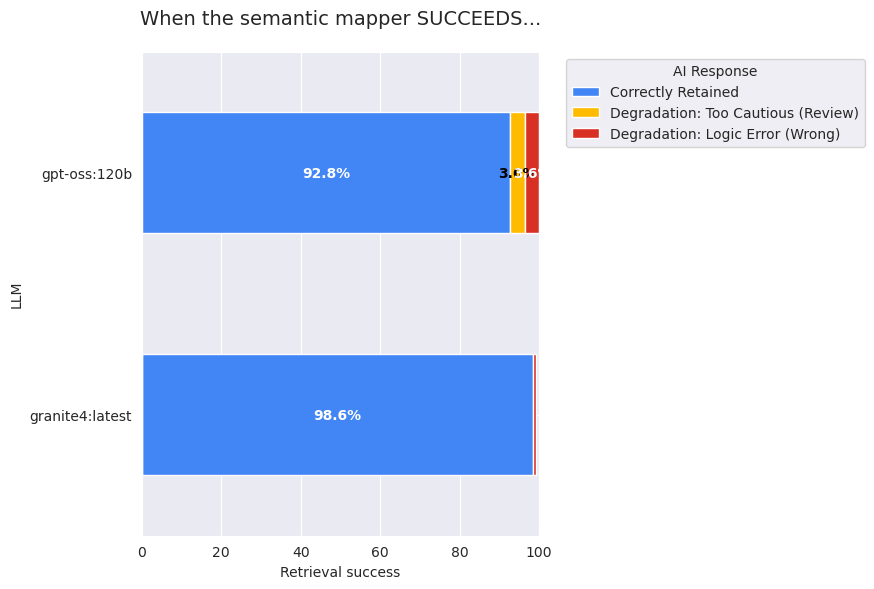

In [16]:
plot_llm_degradation_analysis(eval_50_dict)


LLM: selector_output_granite4:latest_25_NCBI_LNC
  Samples     : 163
  Hits@1      : 138 / 163  (84.66%)
  Accuracy    : 138 / 163  (84.66%)

  Failures breakdown:
    Wrong code       : 20
    NaN              : 5
    Needs_Review     : 0
    Empty candidates : 0

  --- WRONG failures ---
     CUI                                  longest_NCBI_name                              ground_truth_LNC    AI_code                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             se_codes
C0012984  

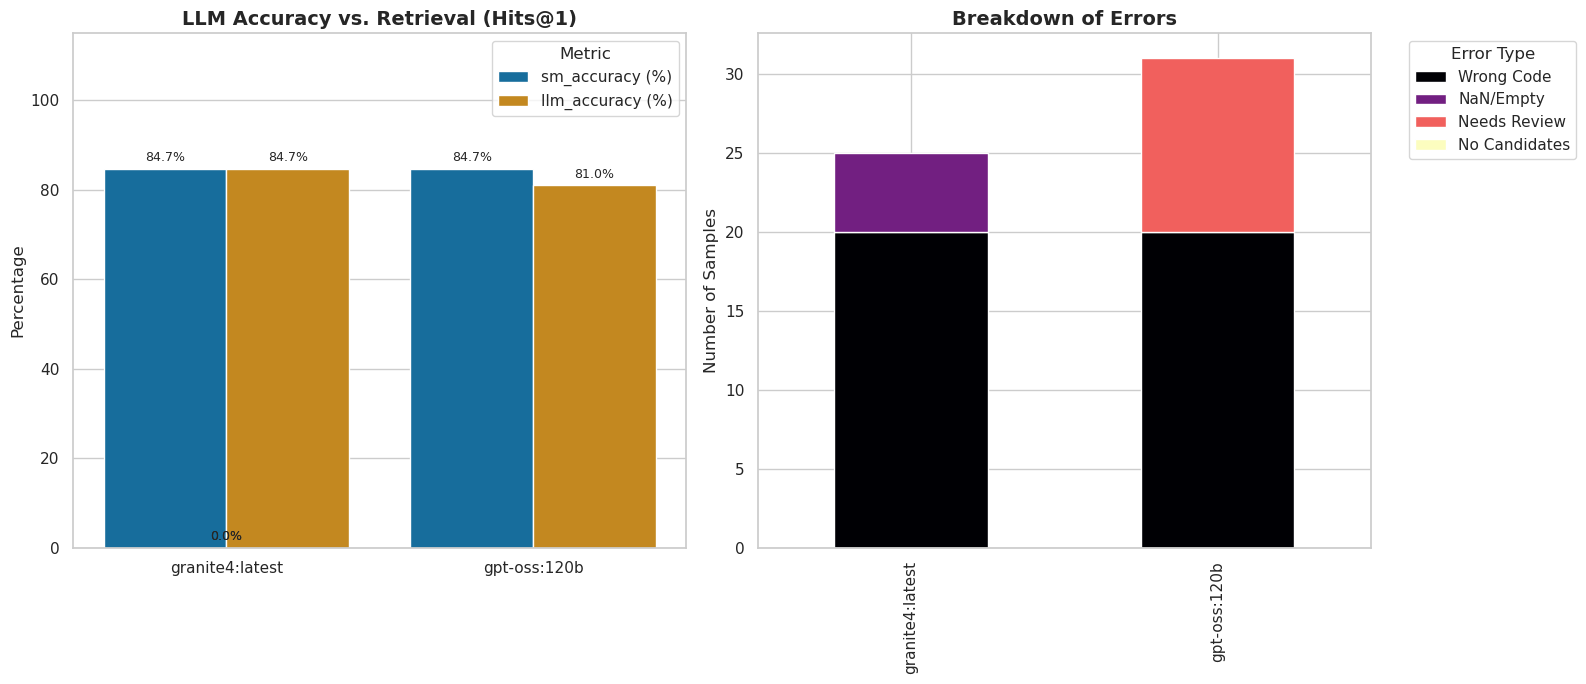

In [19]:
llm_models =  ['granite4:latest', 'gpt-oss:120b']
files = []

for model in llm_models:
    files.append(f'results/OntoMapping_benchmark/trial_2_k_50/selector_output_{model}_25_NCBI_LNC.csv')

results = evaluate_llm_files(files)

comparison = compare_llms(results)
print("\n\n=== LLM COMPARISON ===")
#print(comparison.to_string())
plot_llm_comparison(comparison, model_names=llm_models)

In [22]:
gpt_failures

{'wrong':          CUI                                  longest_NCBI_name  \
 0   C0012984                             Canis lupus familiaris   
 1   C0014344            "Aerobacter" Hormaeche and Edwards 1958   
 2   C0001699  'Klebsiella aerogenes' (Kruse) Taylor et al. 1956   
 3   C0004589                     Bacillus cereus var. anthracis   
 4   C0014047                   Japanese encephalitis (JE) virus   
 5   C0018481                          Bacillus ulceris cancrosi   
 6   C0023273                   Leishmania (Leishmania) donovani   
 7   C0018019                              Capra aegagrus hircus   
 8   C0085483                     the Ballerup group of bacteria   
 9   C0085479                      Fusobacterium plauti-vincenti   
 10  C0043409                     Pasteurella pseudotuberculosis   
 11  C0038411                         Streptococcus erysipelatos   
 12  C0314836            Aeromonas hybridization group 10 (HG10)   
 13  C0319513                          

In [20]:
comparison

,n_samples,sm_accuracy,sm_accuracy (%),llm_accuracy,llm_accuracy (%),fail_wrong,fail_nan,fail_review,fail_empty_candidates
LLM,,,,,,,,,
selector_output_granite4:latest_25_NCBI_LNC,163,138,84.66,138,84.66,20,5,0,0
selector_output_gpt-oss:120b_25_NCBI_LNC,163,138,84.66,132,80.98,20,0,11,0


In [29]:
for file in files:
    df = pd.read_csv(file)
    print(df['AI_code'].isna().sum())

0
7
149
16


In [10]:
llm_models[3:4]

['qwen3.5:35b']

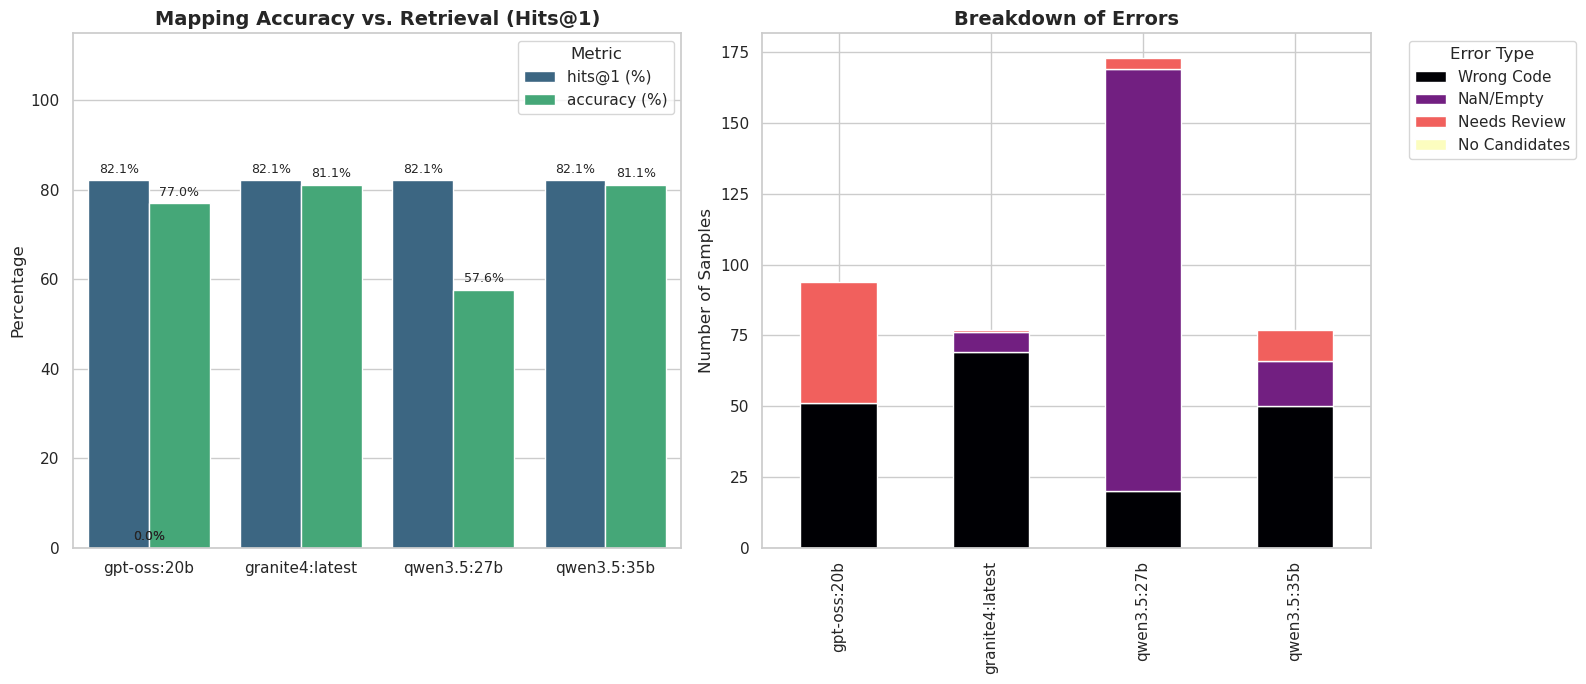

In [59]:
llm_models = ['gpt-oss:20b', 'granite4:latest', 'qwen3.5:27b', 'qwen3.5:35b']
plot_llm_comparison(comparison, model_names=llm_models)

In [ ]:
gpt_df

### Best supervisor

In [24]:
llm_models = ['gemma4:latest', 'gpt-oss:120b', 'qwen3.5:4b', 'gpt-oss:20b']

In [25]:
with open('results/OntoMapping_benchmark/llms_benchmarking/supervisor_llm/computational_time_selector.txt', 'r') as file:
    time_supervisor = file.read()

time_supervisor

'gemma4:latest: 00:20:44 \ngpt-oss:120b: 01:10:13 \nqwen3.5:4b: 01:31:14 \ngpt-oss:20b: 00:08:39 \n'

In [26]:
eval_dict = {llm: evaluate_dataframe(read_res_file(llm, 'NCBI', 'LNC'))[0] for llm in llm_models}
eval_dict[llm_models[0]]

,CUI,longest_NCBI_name,ground_truth_LNC,se_codes,AI_code,hit1,accurate,fail_cat
0,C0014323,Entamoeba histolytica,"[LP16698-0, MTHU004659, LA19278-3]","[LP16698-0, LA19278-3, MTHU004659, LP16698-0, ...",LP16698-0,True,True,None
1,C0242906,Neospora caninum,[LP14266-8],"[LP14266-8, LP14266-8, MTHU011493, LP422154-7,...",LP14266-8,True,True,None
2,C0319923,Aspergillus terrestris,"[LP13999-5, LA19331-0]","[LP13999-5, LA19331-0, LP13999-5, LP36664-8, L...",LP13999-5,True,True,None
3,C0033734,Prototheca,"[LP14843-4, MTHU071111]","[MTHU071111, LP14843-4, LP14843-4, 10713-6, 10...",MTHU071111,True,True,None
4,C0260106,Penicillium digitatum,[LP427109-6],"[LP427109-6, LP427109-6, MTHU066532, LP427108-...",LP427109-6,True,True,None
...,...,...,...,...,...,...,...,...
158,C0949895,Sudan Ebola virus,[LP434522-1],"[LG32761-5, LP17696-3, LP17696-3, LP185762-4, ...",,False,False,nan
159,C1024145,Ustilago carbo AY cynodontis,"[LP17624-5, LP17624-5]","[LP17624-5, LP17624-5, MTHU024165, LP147936-1,...",LP17624-5,True,True,None
160,C0446025,Helminthosporium spiciferum,[LA32432-9],"[LA32432-9, LP17065-1]",LA32432-9,True,True,None
161,C1047380,Ulmus crassifolia,"[LP199461-7, LP199461-7]","[LP199461-7, LP199461-7, LP13920-1, LP13920-1,...",LP199461-7,True,True,None


In [19]:
eval_dict[llm_models[1]].head()

,CUI,longest_NCBI_name,ground_truth_LNC,se_codes,AI_code,hit1,accurate,fail_cat
0,C0014323,Entamoeba histolytica,"[LP16698-0, MTHU004659, LA19278-3]","[LP16698-0, LA19278-3, MTHU004659, LP16698-0, ...",,True,False,nan
1,C0242906,Neospora caninum,[LP14266-8],"[LP14266-8, LP14266-8, MTHU011493, LP422154-7,...",,True,False,nan
2,C0319923,Aspergillus terrestris,"[LP13999-5, LA19331-0]","[LP13999-5, LA19331-0, LP13999-5, LP36664-8, L...",,True,False,nan
3,C0033734,Prototheca,"[LP14843-4, MTHU071111]","[MTHU071111, LP14843-4, LP14843-4, 10713-6, 10...",,True,False,nan
4,C0260106,Penicillium digitatum,[LP427109-6],"[LP427109-6, LP427109-6, MTHU066532, LP427108-...",,True,False,nan



LLM: supervisor_output_gemma4:latest_25_NCBI_LNC
  Samples     : 163
  Hits@1      : 138 / 163  (84.66%)
  Accuracy    : 135 / 163  (82.82%)

  Failures breakdown:
    Wrong code       : 24
    NaN              : 3
    Needs_Review     : 1
    Empty candidates : 0

  --- WRONG failures ---
     CUI                            longest_NCBI_name                              ground_truth_LNC    AI_code                                                     se_codes
C0319600                  Zygosaccharomyces marxianus                       [LP321649-8, LA32404-8] LP310485-0  [LP310485-0, LP310485-0, LA28242-8, LP321647-2, LP321647-2]
C0023273             Leishmania (Leishmania) donovani                                   [LA28383-0]  LP18310-0    [LP18310-0, LP18310-0, LA28383-0, LP201736-8, LP201736-8]
C0085483               the Ballerup group of bacteria                       [LA29360-7, LP429501-2]  LP30576-0     [LP30576-0, LA30664-9, LP30576-0, LP36837-0, LP442420-8]
C0314836      Aeromo

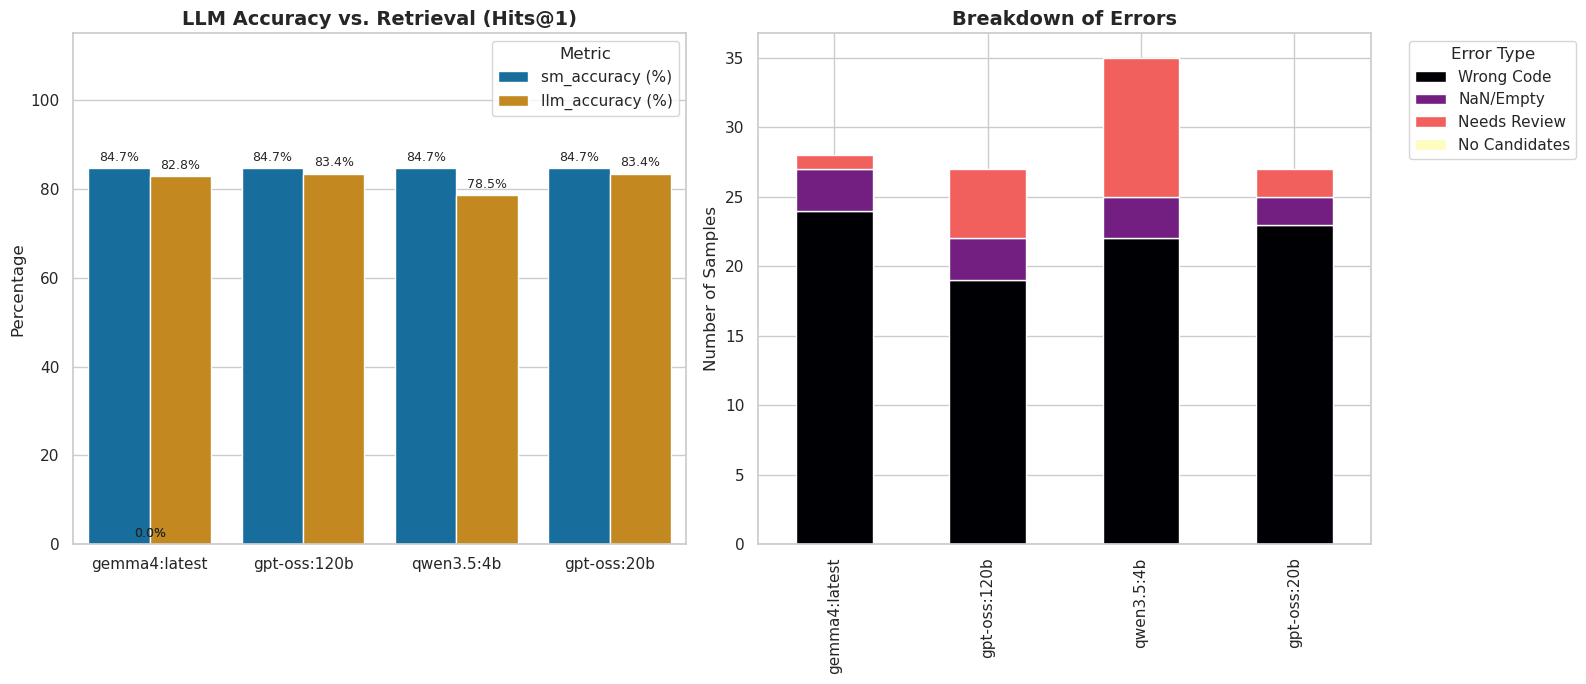

In [27]:

files = []

for model in llm_models:
    files.append(f'results/OntoMapping_benchmark/llms_benchmarking/supervisor_llm/supervisor_output_{model}_25_NCBI_LNC.csv')

results = evaluate_llm_files(files)

comparison = compare_llms(results)
print("\n\n=== LLM COMPARISON ===")
#print(comparison.to_string())
plot_llm_comparison(comparison, model_names=llm_models)

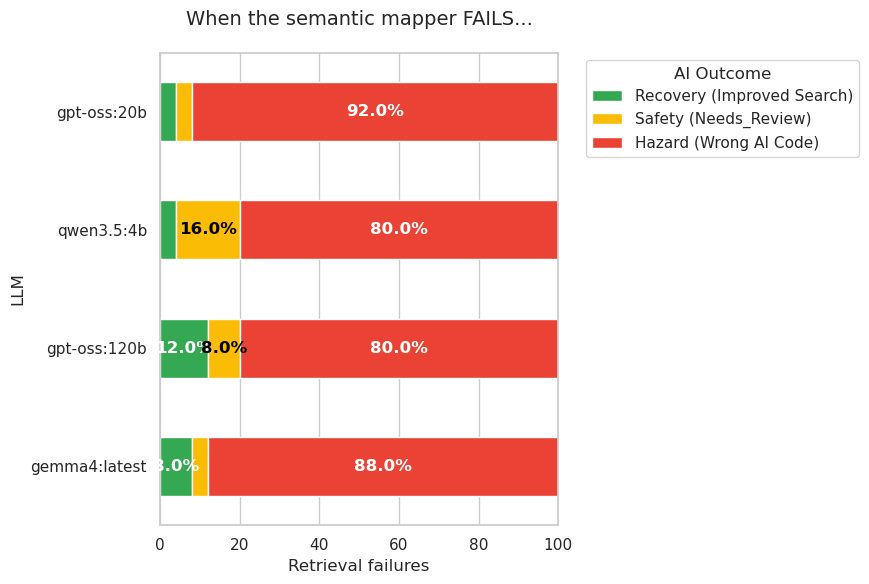

In [28]:
plot_llm_intervention_analysis(eval_dict)

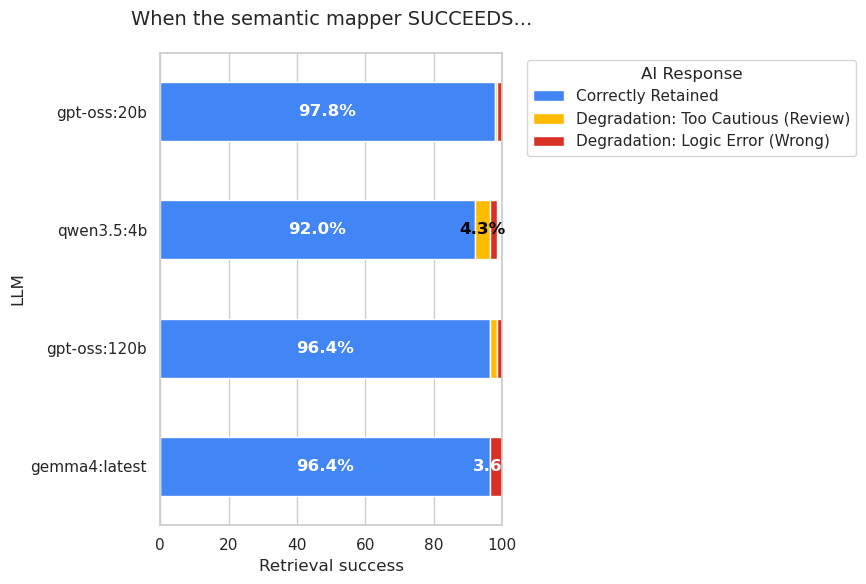

In [29]:
plot_llm_degradation_analysis(eval_dict)
